In [1]:
%load_ext autoreload
%autoreload 2

import btp_part1_data_labels as part_one
import thesis_part2_six_features as part_two

close, volume = part_one.load_market_data()


In [2]:
features = part_two.build_features(close).loc[part_one.ANALYSIS_START:]
features.to_parquet("features_raw.parquet")

In [3]:
part_two.diagnostics(features)


=== Feature correlation matrix (investigate any pair above 0.8 in absolute value) ===
                              markov_switching_probability  volatility_term_structure  credit_appetite_change  yield_curve_slope  real_yield_change  average_pairwise_correlation
markov_switching_probability                          1.00                       0.64                   -0.14              -0.19               0.13                         -0.01
volatility_term_structure                             0.64                       1.00                   -0.23              -0.21               0.08                         -0.03
credit_appetite_change                               -0.14                      -0.23                    1.00               0.06               0.47                          0.12
yield_curve_slope                                    -0.19                      -0.21                    0.06               1.00              -0.03                         -0.30
real_yield_change      

c:\Users\ganju\OneDrive\Desktop\BTP Project\thesis_part2_six_features.py:108: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_value = adfuller(features[column].dropna())[1]
c:\Users\ganju\OneDrive\Desktop\BTP Project\thesis_part2_six_features.py:108: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_value = adfuller(features[column].dropna())[1]
c:\Users\ganju\OneDrive\Desk

credit_appetite_change           0.0000
yield_curve_slope                0.4868
real_yield_change                0.0000


c:\Users\ganju\OneDrive\Desktop\BTP Project\thesis_part2_six_features.py:108: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_value = adfuller(features[column].dropna())[1]
c:\Users\ganju\OneDrive\Desktop\BTP Project\thesis_part2_six_features.py:108: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_value = adfuller(features[column].dropna())[1]
c:\Users\ganju\OneDrive\Desk

average_pairwise_correlation     0.0351

=== Missing values per feature inside the analysis window ===
markov_switching_probability    0
volatility_term_structure       0
credit_appetite_change          0
yield_curve_slope               0
real_yield_change               0
average_pairwise_correlation    0


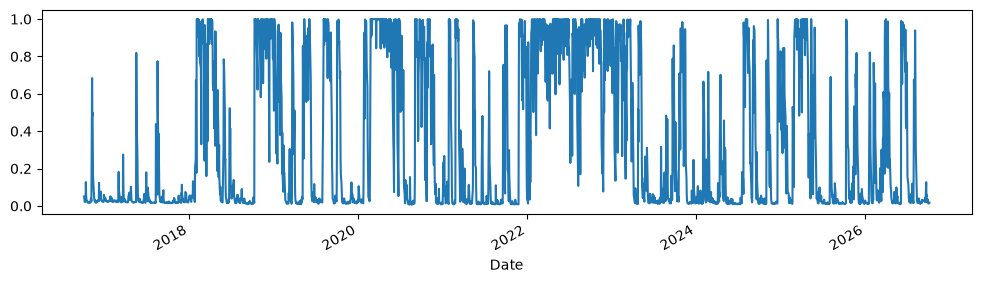

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

features["markov_switching_probability"].plot(figsize=(12, 3))
plt.show()

In [11]:
features.dropna().to_parquet("features.parquet")